# CROP Prediction


In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
db = pd.read_csv("standardized_crops.csv")
db.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple


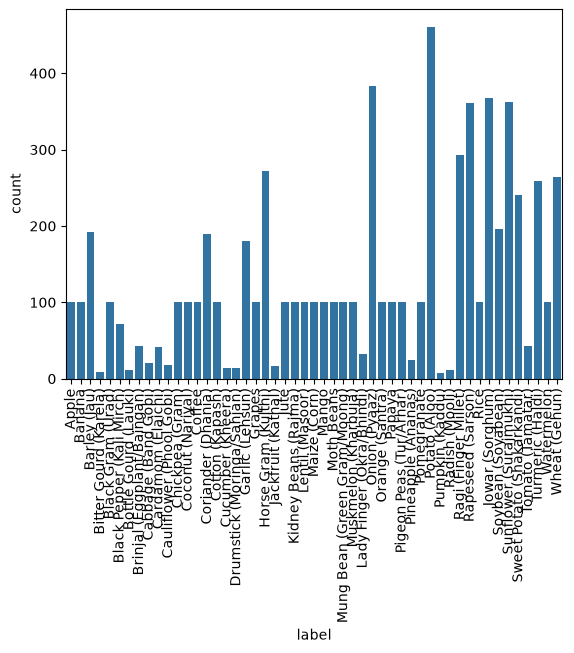

In [3]:
sns.countplot(data=db,x='label')
plt.xticks(rotation=90)
plt.show()

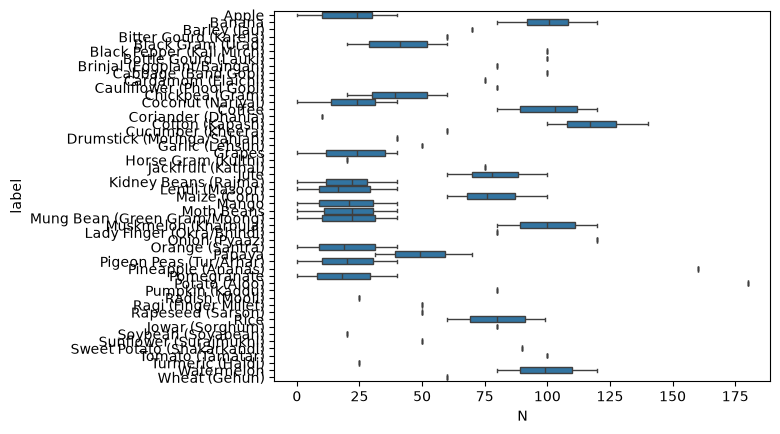

In [19]:
sns.boxplot(data=db,x='N',y='label')
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
encoder = LabelEncoder()
model = LogisticRegression(max_iter=5000)
scaler = StandardScaler()


X = db.drop('label',axis=1)
y = encoder.fit_transform(db['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2 ,random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

model.fit(X_train,y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test,predictions)
print("Accuracy :", accuracy)

Accuracy : 0.9272727272727272


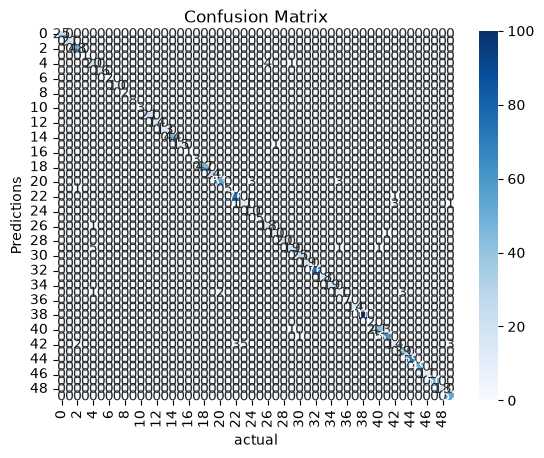

In [13]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score

cm = confusion_matrix(y_test,predictions)
acc = accuracy_score(y_test,predictions)
rs = recall_score(y_test,predictions,average="weighted")
fs = f1_score(y_test,predictions,average="weighted")


sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("actual")
plt.ylabel("Predictions")
plt.title("Confusion Matrix")
plt.show()